In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_colwidth', None)

In [12]:
df = pd.read_csv("dataset_clean_views_with_duration.csv")

In [13]:
df.head()

,author,video_url,title,caption,create_time_unix,create_date_utc,shares,comments,likes,subs,views_per_sub,num_views,video_id,duration
0,bankerthichcode,https://www.tiktok.com/@bankerthichcode/video/7573978385748069639,Lộ trình 9 ngày học AI hiệu quả | TikTok,Lộ trình học tập sử dụng AI trong vòng 9 ngày để làm quen và sử dụng thành thạo các công cụ trí tuệ nhân tạo #CapCut #bankerthichcode #ai9ngayyeu #BookTok #xahoi,1.763454e+09,2025-11-18,386.0,94.0,7457.0,573700,NaN,529700,7.573978e+18,176.0
1,bankerthichcode,https://www.tiktok.com/@bankerthichcode/video/7538098035327257864,Sống đời rủng rỉnh và thong dong: Hướng dẫn tài chính | TikTok,"Sống đời rủng rỉnh và thong dong, định hướng cho bạn 1 cuộc sống thong dong và an tâm tài chính bằng nhiều góc nhìn #bankerthichcode #giverbooks #taichinh #dautu #CapCut",1.755100e+09,2025-08-13,662.0,222.0,15000.0,573700,NaN,1500000,7.538098e+18,137.0
2,bankerthichcode,https://www.tiktok.com/@bankerthichcode/video/7554383805675506962,NaN,NaN,NaN,NaN,NaN,NaN,NaN,573700,NaN,1200000,7.554384e+18,NaN
3,bankerthichcode,https://www.tiktok.com/@bankerthichcode/video/7612643973269622037,Mỹ và Iran #bankerthichcode #chinhtri #CapCut | TikTok,Mỹ và Iran #bankerthichcode #chinhtri #CapCut,1.772457e+09,2026-03-02,407.0,432.0,13600.0,573700,NaN,408100,7.612644e+18,162.0
4,bankerthichcode,https://www.tiktok.com/@bankerthichcode/video/7611918335776656661,"Mỹ Israel đã xung đột với Iran, giá vàng và giá dầu sẽ tăng hay giảm #... | TikTok","Mỹ Israel đã xung đột với Iran, giá vàng và giá dầu sẽ tăng hay giảm #CapCut #bankerthichcode #gold #vang #chinhtri",1.772288e+09,2026-02-28,1270.0,314.0,16300.0,573700,NaN,585900,7.611918e+18,193.0


In [14]:
df["views_per_sub"] = (df["num_views"] / df["subs"]) * 100

In [15]:
df["engagement_rate"] = ((df["likes"] + df["comments"] + df["shares"]) / df["num_views"]) * 100

In [16]:
df = df.dropna()

In [17]:
df["create_time_unix"] = pd.to_datetime(df["create_time_unix"], unit="s")

In [28]:
df["comment_rate"] = df["comments"] / df["num_views"] * 100
df["share_rate"] = df["shares"] / df["num_views"] * 100
df["like_rate"] = df["likes"] / df["num_views"] * 100

In [29]:
df.head()

,author,video_url,title,caption,create_time_unix,create_date_utc,shares,comments,likes,subs,views_per_sub,num_views,video_id,duration,engagement_rate,comment_rate,share_rate,like_rate
0,bankerthichcode,https://www.tiktok.com/@bankerthichcode/video/7573978385748069639,Lộ trình 9 ngày học AI hiệu quả | TikTok,Lộ trình học tập sử dụng AI trong vòng 9 ngày để làm quen và sử dụng thành thạo các công cụ trí tuệ nhân tạo #CapCut #bankerthichcode #ai9ngayyeu #BookTok #xahoi,2025-11-18 08:24:29,2025-11-18,386.0,94.0,7457.0,573700,92.330486,529700,7.573978e+18,176.0,1.498395,0.017746,0.072871,1.407778
1,bankerthichcode,https://www.tiktok.com/@bankerthichcode/video/7538098035327257864,Sống đời rủng rỉnh và thong dong: Hướng dẫn tài chính | TikTok,"Sống đời rủng rỉnh và thong dong, định hướng cho bạn 1 cuộc sống thong dong và an tâm tài chính bằng nhiều góc nhìn #bankerthichcode #giverbooks #taichinh #dautu #CapCut",2025-08-13 15:50:22,2025-08-13,662.0,222.0,15000.0,573700,261.460694,1500000,7.538098e+18,137.0,1.058933,0.014800,0.044133,1.000000
3,bankerthichcode,https://www.tiktok.com/@bankerthichcode/video/7612643973269622037,Mỹ và Iran #bankerthichcode #chinhtri #CapCut | TikTok,Mỹ và Iran #bankerthichcode #chinhtri #CapCut,2026-03-02 13:06:47,2026-03-02,407.0,432.0,13600.0,573700,71.134739,408100,7.612644e+18,162.0,3.538103,0.105856,0.099730,3.332517
4,bankerthichcode,https://www.tiktok.com/@bankerthichcode/video/7611918335776656661,"Mỹ Israel đã xung đột với Iran, giá vàng và giá dầu sẽ tăng hay giảm #... | TikTok","Mỹ Israel đã xung đột với Iran, giá vàng và giá dầu sẽ tăng hay giảm #CapCut #bankerthichcode #gold #vang #chinhtri",2026-02-28 14:10:50,2026-02-28,1270.0,314.0,16300.0,573700,102.126547,585900,7.611918e+18,193.0,3.052398,0.053593,0.216761,2.782045
5,bankerthichcode,https://www.tiktok.com/@bankerthichcode/video/7610784575698013460,Vấn đề tại Mexico: Những Bất Cập Cần Khám Phá | TikTok,Vấn đề tại Mexico phần 1 #bankerthichcode #chinhtri #CapCut,2026-02-25 12:51:17,2026-02-25,190.0,95.0,7717.0,573700,43.001569,246700,7.610785e+18,139.0,3.243616,0.038508,0.077017,3.128091


In [31]:
df.groupby("author")["views_per_sub"].mean()

author
bankerthichcode       148.597752
luuluongchiasenews    145.267769
stevent107            102.597913
Name: views_per_sub, dtype: float64

In [41]:
df.groupby(pd.cut(df["duration"], bins=[0,15,30,60,120,200,300,350,400,500]))["views_per_sub"].mean()

C:\Users\ukhal\AppData\Local\Temp\ipykernel_18016\3080287792.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(pd.cut(df["duration"], bins=[0,15,30,60,120,200,300,350,400,500]))["views_per_sub"].mean()


duration
(0, 15]              NaN
(15, 30]       55.754177
(30, 60]       54.828762
(60, 120]     114.780190
(120, 200]    153.958324
(200, 300]    249.024264
(300, 350]     66.875050
(350, 400]    108.618626
(400, 500]     19.727077
Name: views_per_sub, dtype: float64

In [40]:
df.groupby(pd.cut(df["duration"], bins=[0,15,30,60,120,200,250,300,350,400,500]))["engagement_rate"].mean()

C:\Users\ukhal\AppData\Local\Temp\ipykernel_18016\115080941.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(pd.cut(df["duration"], bins=[0,15,30,60,120,200,250,300,350,400,500]))["engagement_rate"].mean()


duration
(0, 15]             NaN
(15, 30]       3.491253
(30, 60]       2.424184
(60, 120]      2.582003
(120, 200]    10.592309
(200, 250]     5.076429
(250, 300]     3.518167
(300, 350]     4.239893
(350, 400]     1.422526
(400, 500]     1.334951
Name: engagement_rate, dtype: float64

In [42]:
df.groupby("author")["duration"].mean()

author
bankerthichcode       143.287611
luuluongchiasenews     86.834783
stevent107            124.469565
Name: duration, dtype: float64

In [43]:
df.groupby("author")["engagement_rate"].mean()

author
bankerthichcode        3.785886
luuluongchiasenews     2.466724
stevent107            11.527734
Name: engagement_rate, dtype: float64

In [44]:
df.groupby("author")["views_per_sub"].mean()

author
bankerthichcode       148.597752
luuluongchiasenews    145.267769
stevent107            102.597913
Name: views_per_sub, dtype: float64

In [20]:
top_comments = df.nlargest(10, "comments")[
    ["video_url", "num_views", "likes", "comments", "shares", "duration"]
]

top_comments.head(10)

,video_url,num_views,likes,comments,shares,duration
190,https://www.tiktok.com/@bankerthichcode/video/7526457483209084178,10100000,308400.0,10900.0,31500.0,134.0
193,https://www.tiktok.com/@bankerthichcode/video/7525714200686054674,5300000,311500.0,9811.0,47900.0,173.0
143,https://www.tiktok.com/@bankerthichcode/video/7545182472884030738,4700000,291600.0,6181.0,25600.0,177.0
132,https://www.tiktok.com/@bankerthichcode/video/7549590951220628754,4200000,251300.0,4782.0,28000.0,216.0
198,https://www.tiktok.com/@bankerthichcode/video/7522435289252433159,8900000,292200.0,4523.0,39000.0,299.0
57,https://www.tiktok.com/@bankerthichcode/video/7584066636773149960,7200000,214800.0,3352.0,8001.0,136.0
642,https://www.tiktok.com/@luuluongchiasenews/video/7603502248567541005,2000000,54100.0,3131.0,25400.0,60.0
189,https://www.tiktok.com/@bankerthichcode/video/7527169958829198610,9100000,255600.0,3038.0,18600.0,183.0
133,https://www.tiktok.com/@bankerthichcode/video/7548874981032070418,2000000,78200.0,2662.0,5003.0,192.0
179,https://www.tiktok.com/@bankerthichcode/video/7530837494548466951,2200000,81700.0,2633.0,2288.0,240.0


In [21]:
top_likes = df.nlargest(10, "likes")[
    ["video_url", "num_views", "likes", "comments", "shares", "duration"]
]

top_likes.head(10)

,video_url,num_views,likes,comments,shares,duration
214,https://www.tiktok.com/@bankerthichcode/video/7513565103762050312,11500000,548300.0,0.0,28300.0,90.0
193,https://www.tiktok.com/@bankerthichcode/video/7525714200686054674,5300000,311500.0,9811.0,47900.0,173.0
190,https://www.tiktok.com/@bankerthichcode/video/7526457483209084178,10100000,308400.0,10900.0,31500.0,134.0
198,https://www.tiktok.com/@bankerthichcode/video/7522435289252433159,8900000,292200.0,4523.0,39000.0,299.0
143,https://www.tiktok.com/@bankerthichcode/video/7545182472884030738,4700000,291600.0,6181.0,25600.0,177.0
189,https://www.tiktok.com/@bankerthichcode/video/7527169958829198610,9100000,255600.0,3038.0,18600.0,183.0
132,https://www.tiktok.com/@bankerthichcode/video/7549590951220628754,4200000,251300.0,4782.0,28000.0,216.0
57,https://www.tiktok.com/@bankerthichcode/video/7584066636773149960,7200000,214800.0,3352.0,8001.0,136.0
578,https://www.tiktok.com/@luuluongchiasenews/video/7606556606981065998,7300000,150300.0,2460.0,27500.0,99.0
164,https://www.tiktok.com/@bankerthichcode/video/7536602540733959442,1800000,109900.0,833.0,3118.0,185.0


In [22]:
top_shares = df.nlargest(10, "shares")[
    ["video_url", "num_views", "likes", "comments", "shares", "duration"]
]

top_shares.head(10)

,video_url,num_views,likes,comments,shares,duration
193,https://www.tiktok.com/@bankerthichcode/video/7525714200686054674,5300000,311500.0,9811.0,47900.0,173.0
463,https://www.tiktok.com/@luuluongchiasenews/video/7588704447690263821,2400000,65600.0,1141.0,45800.0,73.0
198,https://www.tiktok.com/@bankerthichcode/video/7522435289252433159,8900000,292200.0,4523.0,39000.0,299.0
190,https://www.tiktok.com/@bankerthichcode/video/7526457483209084178,10100000,308400.0,10900.0,31500.0,134.0
214,https://www.tiktok.com/@bankerthichcode/video/7513565103762050312,11500000,548300.0,0.0,28300.0,90.0
462,https://www.tiktok.com/@luuluongchiasenews/video/7602326175456791821,3900000,52100.0,2029.0,28100.0,155.0
132,https://www.tiktok.com/@bankerthichcode/video/7549590951220628754,4200000,251300.0,4782.0,28000.0,216.0
578,https://www.tiktok.com/@luuluongchiasenews/video/7606556606981065998,7300000,150300.0,2460.0,27500.0,99.0
143,https://www.tiktok.com/@bankerthichcode/video/7545182472884030738,4700000,291600.0,6181.0,25600.0,177.0
649,https://www.tiktok.com/@luuluongchiasenews/video/7603054326155578637,1200000,22800.0,359.0,25500.0,90.0


In [69]:
top_engagement = df.nlargest(30, "engagement_rate")[
    ["video_url", "views_per_sub", "engagement_rate", "duration", "shares", "comments", "likes"]
]

top_engagement.head(30)

,video_url,views_per_sub,engagement_rate,duration,shares,comments,likes
232,https://www.tiktok.com/@stevent107/video/7613768642282507540,0.340987,2034.006734,127.0,55.0,265.0,5721.0
233,https://www.tiktok.com/@stevent107/video/7613760408851107092,8.816303,15.301472,121.0,18.0,46.0,1111.0
688,https://www.tiktok.com/@luuluongchiasenews/video/7600256833202261278,56.451999,12.958863,65.0,25100.0,90.0,5367.0
140,https://www.tiktok.com/@bankerthichcode/video/7546599625872919815,20.533380,9.676570,213.0,290.0,209.0,10900.0
191,https://www.tiktok.com/@bankerthichcode/video/7526177646514834706,91.702981,8.630108,165.0,2226.0,1377.0,41800.0
142,https://www.tiktok.com/@bankerthichcode/video/7545390989939100935,95.886352,8.351754,156.0,3575.0,468.0,41900.0
120,https://www.tiktok.com/@bankerthichcode/video/7556641239001533704,16.280286,8.238758,156.0,327.0,174.0,7194.0
34,https://www.tiktok.com/@bankerthichcode/video/7594471808716311828,97.594562,8.080014,29.0,995.0,745.0,43500.0
62,https://www.tiktok.com/@bankerthichcode/video/7580555082136161554,143.454767,7.934508,341.0,18800.0,2001.0,44500.0
664,https://www.tiktok.com/@luuluongchiasenews/video/7602088129826131255,174.910223,7.722009,62.0,15400.0,217.0,40800.0


In [24]:
df.describe()

,create_time_unix,shares,comments,likes,subs,views_per_sub,num_views,video_id,duration,engagement_rate
count,686,686.000000,686.000000,686.000000,686.000000,686.000000,6.860000e+02,6.860000e+02,686.000000,686.000000
mean,2025-12-23 06:43:29.413994240,1504.186589,348.728863,15828.577259,358251.020408,132.058599,5.142563e+05,7.586940e+18,118.051020,5.939265
min,2025-05-21 14:11:21,0.000000,0.000000,10.000000,87100.000000,0.340987,2.970000e+02,7.506901e+18,19.000000,0.374133
25%,2025-11-28 13:17:08.500000,22.000000,23.000000,1407.000000,87100.000000,26.663710,5.977500e+04,7.577765e+18,81.000000,2.106425
50%,2026-01-27 05:30:37,138.500000,89.500000,3955.000000,417700.000000,67.857765,1.724500e+05,7.599910e+18,112.000000,2.715664
75%,2026-02-13 06:48:38.249999872,705.000000,354.250000,15600.000000,573700.000000,145.307121,5.428500e+05,7.606238e+18,146.000000,3.427795
max,2026-03-05 13:51:01,47900.000000,10900.000000,548300.000000,573700.000000,2004.531985,1.150000e+07,7.613769e+18,499.000000,2034.006734
std,NaN,4860.987328,797.487111,38654.666913,202947.803560,219.126005,1.053104e+06,2.787644e+16,48.821875,77.559091


In [ ]:
largest_views_per_sub = df.nlargest(30, "views_per_sub")[
    ["video_url", "views_per_sub", "engagement_rate", "duration", "shares", "comments", "likes"]
]

largest_views_per_sub.head(30)

,video_url,views_per_sub,engagement_rate,duration,shares,comments,likes
214,https://www.tiktok.com/@bankerthichcode/video/7513565103762050312,2004.531985,5.013913,90.0,28300.0,0.0,548300.0
190,https://www.tiktok.com/@bankerthichcode/video/7526457483209084178,1760.502005,3.473267,134.0,31500.0,10900.0,308400.0
578,https://www.tiktok.com/@luuluongchiasenews/video/7606556606981065998,1747.665789,2.469315,99.0,27500.0,2460.0,150300.0
427,https://www.tiktok.com/@stevent107/video/7583603906735901973,1722.158439,2.511533,126.0,429.0,544.0,36700.0
189,https://www.tiktok.com/@bankerthichcode/video/7527169958829198610,1586.194875,3.046571,183.0,18600.0,3038.0,255600.0
198,https://www.tiktok.com/@bankerthichcode/video/7522435289252433159,1551.333450,3.772169,299.0,39000.0,4523.0,292200.0
437,https://www.tiktok.com/@stevent107/video/7581063251644009746,1377.726751,1.923583,130.0,410.0,1073.0,21600.0
57,https://www.tiktok.com/@bankerthichcode/video/7584066636773149960,1255.011330,3.141014,136.0,8001.0,3352.0,214800.0
576,https://www.tiktok.com/@luuluongchiasenews/video/7606751967129521422,1197.031362,1.863560,62.0,4422.0,1956.0,86800.0
529,https://www.tiktok.com/@luuluongchiasenews/video/7609940155436174606,981.565478,2.600732,90.0,8045.0,885.0,97700.0


In [53]:
df["viral"] = df["views_per_sub"] > df["views_per_sub"].quantile(0.9)

                views_per_sub  count
duration                            
(18.52, 67.0]       34.318889     76
(67.0, 115.0]       51.280824    287
(115.0, 163.0]      78.623762    218
(163.0, 211.0]     104.305386     83
(211.0, 259.0]     191.598396     14


C:\Users\ukhal\AppData\Local\Temp\ipykernel_18016\2030434192.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby(pd.cut(df.duration, bins=10)).agg(


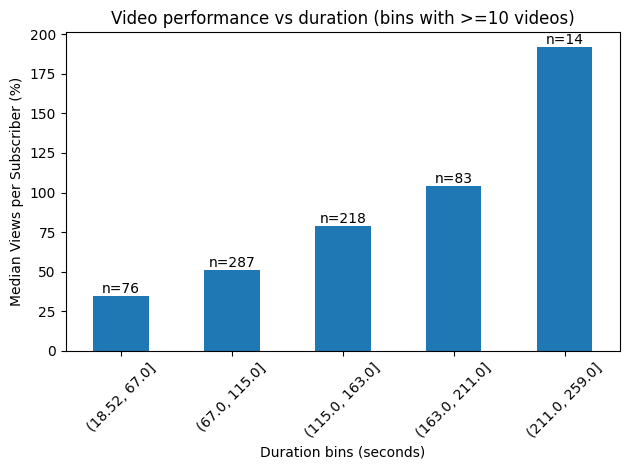

In [ ]:
import matplotlib.pyplot as plt

grouped = df.groupby(pd.cut(df.duration, bins=10)).agg(
    views_per_sub=("views_per_sub", "median"),
    count=("views_per_sub", "count")
)

grouped = grouped[grouped["count"] >= 10]

print(grouped)

for i, v in enumerate(grouped["views_per_sub"]):
    plt.text(i, v, f'n={grouped["count"].iloc[i]}', ha='center', va='bottom')

grouped["views_per_sub"].plot(kind="bar")

plt.ylabel("Median Views per Subscriber (%)")
plt.xlabel("Duration bins (seconds)")
plt.title("Video performance vs duration (bins with >=10 videos)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

BEST TIME

In [77]:
df["datetime"] = pd.to_datetime(df["create_time_unix"], unit="s", utc=True)
df["datetime"] = df["datetime"].dt.tz_convert("Asia/Ho_Chi_Minh")

In [78]:
df["datetime"] = pd.to_datetime(df["create_time_unix"], unit="s")

df["hour"] = df["datetime"].dt.hour
df["weekday"] = df["datetime"].dt.day_name()

In [79]:
hourly = df.groupby("hour").agg(
    views_per_sub=("views_per_sub", "median"),
    engagement=("engagement_rate", "median"),
    count=("views_per_sub", "count")
)

print(hourly)

      views_per_sub  engagement  count
hour                                  
0        109.887479    2.523794     20
1         62.342135    2.349345     11
2         71.260555    2.565256     28
3         53.312107    2.639124     28
4         70.461581    2.807916     38
5         68.851316    3.015342     37
6         75.532679    2.511533     35
7         71.259746    2.460854     36
8         50.142258    2.778678     32
9         73.592423    2.714953     37
10        71.715496    2.790230     52
11        39.265212    2.892989     29
12        65.695159    2.918980     56
13        66.963186    3.810311     52
14        74.336377    3.149186     50
15        70.400707    3.144976     32
16        51.908663    2.399697     29
17        67.344984    2.859020     25
18        67.728034    1.856250      7
19        33.780225    3.075647      3
20        61.970314    1.994699      8
21        88.029686    1.997836     15
22        66.231745    2.152451     14
23        72.652410    2.

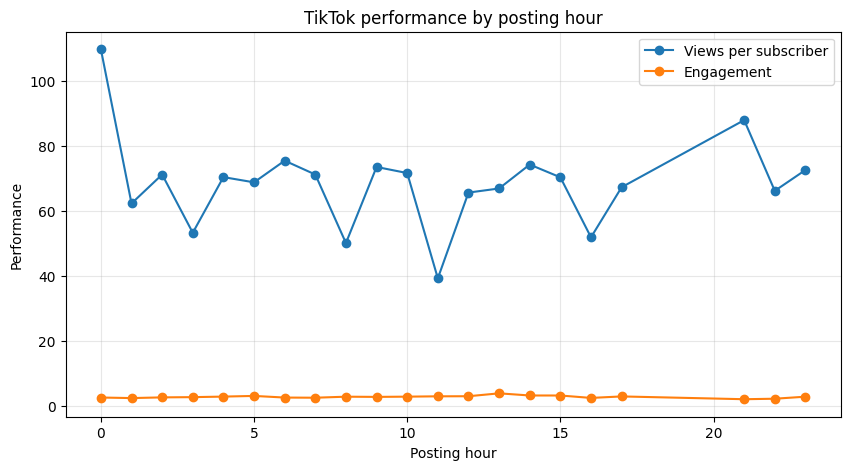

In [80]:
hourly = hourly[hourly["count"] >= 10]

plt.figure(figsize=(10,5))

plt.plot(hourly.index, hourly["views_per_sub"], marker="o", label="Views per subscriber")
plt.plot(hourly.index, hourly["engagement"], marker="o", label="Engagement")

plt.xlabel("Posting hour")
plt.ylabel("Performance")
plt.title("TikTok performance by posting hour")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

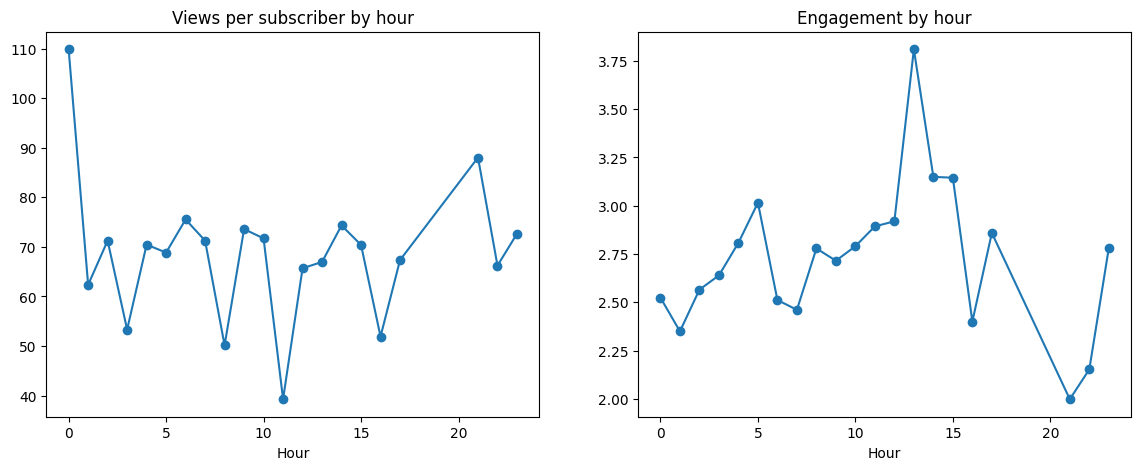

In [81]:
fig, ax = plt.subplots(1,2, figsize=(14,5))

ax[0].plot(hourly.index, hourly["views_per_sub"], marker="o")
ax[0].set_title("Views per subscriber by hour")
ax[0].set_xlabel("Hour")

ax[1].plot(hourly.index, hourly["engagement"], marker="o")
ax[1].set_title("Engagement by hour")
ax[1].set_xlabel("Hour")

plt.show()

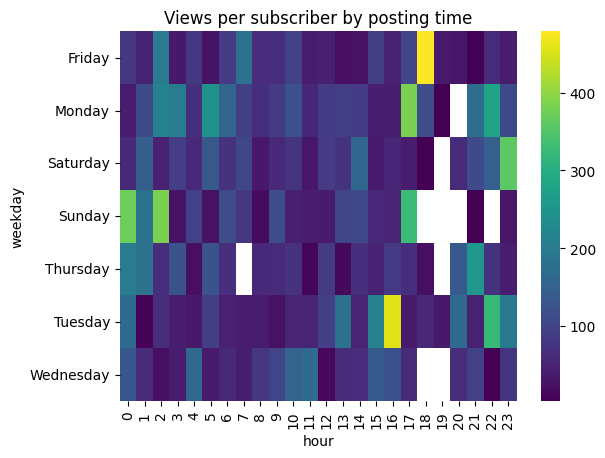

In [82]:
import seaborn as sns

heatmap = df.pivot_table(
    values="views_per_sub",
    index="weekday",
    columns="hour",
    aggfunc="median"
)

sns.heatmap(heatmap, cmap="viridis")

plt.title("Views per subscriber by posting time")
plt.show()

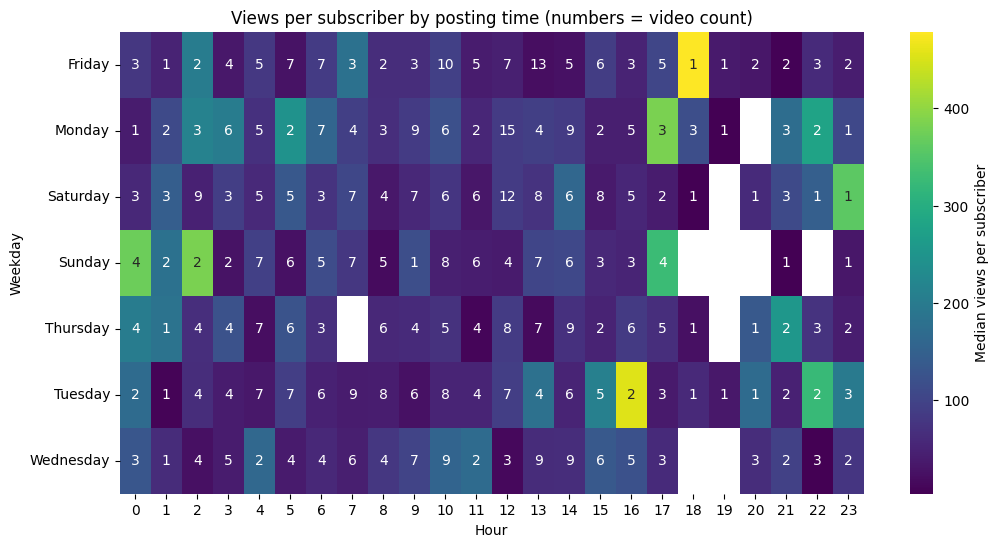

In [85]:
import seaborn as sns
import matplotlib.pyplot as plt

heatmap_values = df.pivot_table(
    values="views_per_sub",
    index="weekday",
    columns="hour",
    aggfunc="median"
)

heatmap_counts = df.pivot_table(
    values="views_per_sub",
    index="weekday",
    columns="hour",
    aggfunc="count"
)

heatmap_counts = heatmap_counts.fillna(0).astype(int)

plt.figure(figsize=(12,6))

sns.heatmap(
    heatmap_values,
    cmap="viridis",
    annot=heatmap_counts,
    fmt="d",
    cbar_kws={'label': 'Median views per subscriber'}
)

plt.title("Views per subscriber by posting time (numbers = video count)")
plt.xlabel("Hour")
plt.ylabel("Weekday")

plt.show()

In [86]:
df[["weekday", "hour"]].isna().sum()

weekday    0
hour       0
dtype: int64

In [87]:
heatmap_counts.sum().sum()

np.int64(686)

In [88]:
len(df)

686

In [89]:
df["time_block"] = pd.cut(
    df["hour"],
    bins=[0,6,12,15,18,21,24],
    labels=["night","morning","midday","afternoon","evening","late"],
    include_lowest=True
)

In [91]:
block_stats = df.groupby("time_block").agg(
    views_per_sub=("views_per_sub", "median"),
    engagement=("engagement_rate", "median"),
    count=("views_per_sub", "count")
)

print(block_stats)

            views_per_sub  engagement  count
time_block                                  
night           72.420397    2.624752    197
morning         66.704937    2.778678    242
midday          69.345580    3.337882    134
afternoon       60.920342    2.491031     61
evening         61.970314    2.013269     26
late            70.952625    2.263193     26


C:\Users\ukhal\AppData\Local\Temp\ipykernel_18016\2589095962.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  block_stats = df.groupby("time_block").agg(


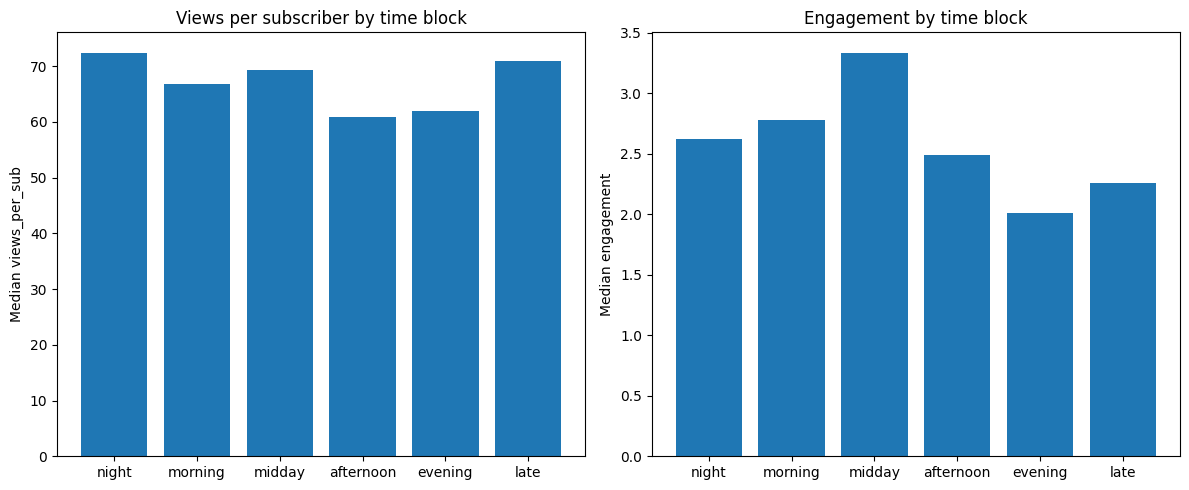

In [92]:
fig, ax = plt.subplots(1,2, figsize=(12,5))

ax[0].bar(block_stats.index.astype(str), block_stats["views_per_sub"])
ax[0].set_title("Views per subscriber by time block")
ax[0].set_ylabel("Median views_per_sub")

ax[1].bar(block_stats.index.astype(str), block_stats["engagement"])
ax[1].set_title("Engagement by time block")
ax[1].set_ylabel("Median engagement")

plt.tight_layout()
plt.show()

C:\Users\ukhal\AppData\Local\Temp\ipykernel_18016\15534130.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  heat = df.pivot_table(


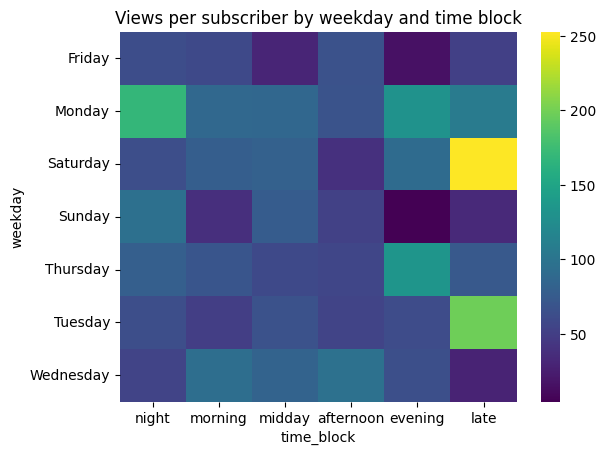

In [94]:
heat = df.pivot_table(
    values="views_per_sub",
    index="weekday",
    columns="time_block",
    aggfunc="median"
)

sns.heatmap(heat, cmap="viridis")
plt.title("Views per subscriber by weekday and time block")
plt.show()

In [97]:
shares_by_block = df.groupby("time_block")["share_rate"].median()
print(shares_by_block)

time_block
night        0.092486
morning      0.043667
midday       0.072705
afternoon    0.135798
evening      0.094855
late         0.176293
Name: share_rate, dtype: float64


C:\Users\ukhal\AppData\Local\Temp\ipykernel_18016\2343187660.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  shares_by_block = df.groupby("time_block")["share_rate"].median()


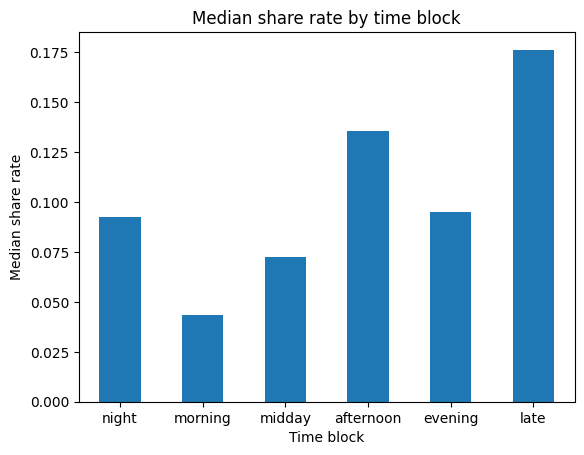

In [99]:
shares_by_block.plot(kind="bar")

plt.title("Median share rate by time block")
plt.xlabel("Time block")
plt.ylabel("Median share rate")
plt.xticks(rotation=0)

plt.show()

C:\Users\ukhal\AppData\Local\Temp\ipykernel_18016\3884455836.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  block_engagement = df.groupby("time_block").agg(


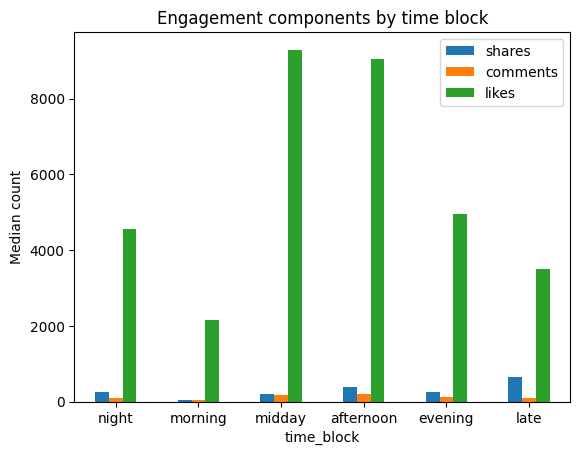

In [100]:
block_engagement = df.groupby("time_block").agg(
    shares=("shares","median"),
    comments=("comments","median"),
    likes=("likes","median")
)

block_engagement.plot(kind="bar")

plt.title("Engagement components by time block")
plt.ylabel("Median count")
plt.xticks(rotation=0)

plt.show()